### **Import Libraries**

In [1]:
!pip install bambi pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 7.6 MB/s eta 0:00:00


In [2]:
import os
import time
from collections import defaultdict
import random
import re
import pandas as pd
import numpy as np

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar, cochrans_q
from scipy.stats import wilcoxon, friedmanchisquare, chi2_contingency, spearmanr
import bambi as bmb
import pymc as pm
import arviz as az

from google.colab import drive
from google.colab.output import eval_js

random.seed(42)


In [3]:
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/st5230_project/output_B')


Mounted at /content/drive


### **Load evals**

In [4]:
# def count_keywords(text, keywords):
#     text = str(text).lower()
#     return sum(len(re.findall(r"\b" + re.escape(k) + r"\b", text)) for k in keywords)

# KEYWORDS_HEDGE = [
#     "perhaps", "maybe", "possibly", "likely",
#     "it seems", "it appears", "i think",
#     "may", "might", "could"
# ]

# KEYWORDS_CONFIDENCE = [
#     "clearly", "definitely", "certainly",
#     "indeed", "in fact", "undoubtedly",
#     "it is clear that"
# ]

# for df in [df_correct, df_hallucinate, df_all]:
#     df["hedging_count"]    = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_HEDGE))
#     df["confidence_count"] = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_CONFIDENCE))
#     df["word_count"]       = df["re_answer"].apply(lambda x: len(x.split()))


In [5]:
KEYWORDS_HEDGE = [
    "perhaps", "maybe", "possibly", "likely",
    "it seems", "it appears", "i think",
    "may", "might", "could"
]

KEYWORDS_CONFIDENCE = [
    "clearly", "definitely", "certainly",
    "indeed", "in fact", "undoubtedly",
    "it is clear that"
]

def count_keywords(text, keywords):
    text = str(text).lower()
    total = 0
    for kw in keywords:
        total += len(re.findall(r"\b" + re.escape(kw) + r"\b", text))
    return total

def add_text_features(df):
    df = df.copy()
    df["question_id"] = df["id"].astype(str)
    df["re_answer"] = df["re_answer"].fillna("").astype(str)
    df["word_count"] = df["re_answer"].apply(lambda x: len(x.split()))
    df["log_length"] = np.log1p(df["word_count"])
    df["hedging_count"] = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_HEDGE))
    df["confidence_count"] = df["re_answer"].apply(lambda x: count_keywords(x, KEYWORDS_CONFIDENCE))
    return df

# Load .csv files
df_correct = pd.read_csv('3b_eval_correct.csv')
df_hallucinate = pd.read_csv('3b_eval_hallucinate.csv')

# Preprocess
df_correct = add_text_features(df_correct)
df_hallucinate = add_text_features(df_hallucinate)

# Concat
df_all = pd.concat([df_correct, df_hallucinate], ignore_index=True)
df_all['question_id'] = df_all['id'].astype(str)

print(df_all.shape)
df_all[['ans_type', 're_fluency', 'ground_truth_ind']].value_counts().sort_index()


(560, 19)


ans_type     re_fluency  ground_truth_ind
correct      honest      1                   140
hallucinate  attack      0                   140
             high        0                   140
             low         0                   140
Name: count, dtype: int64

### **1. Metrics**

#### Bootstrapping

In [8]:
np.random.seed(42)
B = 2000

def bootstrap_ci(df, metric_fn, judge_col, truth_col="ground_truth_ind", B=2000):
    question_ids = df["question_id"].unique()
    n = len(question_ids)
    scores = []
    for _ in range(B):
        sampled_ids = np.random.choice(question_ids, size=n, replace=True)
        sample = df[df["question_id"].isin(sampled_ids)]
        try:
            scores.append(metric_fn(sample[truth_col], sample[judge_col]))
        except:
            continue
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)


#### Accuracy
- Qn: Out of all answers, how often did the judge get the label right?

In [12]:
def calc_acc(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

rows = []
for ans_type, subset in [
    ("overall", df_all),
    ("correct", df_all[df_all["ans_type"]=="correct"]),
    ("hallucinate", df_all[df_all["ans_type"]=="hallucinate"])
]:

    acc_j1 = calc_acc(subset["ground_truth_ind"], subset["judge_1_ind"])
    acc_j2 = calc_acc(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_acc, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_acc, "judge_2_ind")

    rows.append({
        "ans_type": ans_type,
        "Judge 1 (GPT): accuracy": round(acc_j1, 3),
        "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): accuracy": round(acc_j2, 3),
        "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_1 = pd.DataFrame(rows).set_index("ans_type")
metric_1


,Judge 1 (GPT): accuracy,Judge 1 (GPT): 95% CI,Judge 2 (Claude): accuracy,Judge 2 (Claude): 95% CI
ans_type,,,,
overall,0.959,"[0.944, 0.975]",0.884,"[0.86, 0.908]"
correct,0.993,"[0.988, 1.0]",0.743,"[0.689, 0.798]"
hallucinate,0.948,"[0.928, 0.969]",0.931,"[0.906, 0.957]"


#### FAR
- Qn: Among answers that are actually wrong, how often did the judge wrongly say they were correct?

In [13]:
def calc_far(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = (y_true == 0)
    return np.mean(y_pred[mask] == 1)

rows = []
for ans_type, subset in [
    ("overall", df_all),
     ("hallucinate", df_hallucinate)
]:

    far_j1 = calc_far(subset["ground_truth_ind"], subset["judge_1_ind"])
    far_j2 = calc_far(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_far, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_far, "judge_2_ind")

    rows.append({
        "ans_type": ans_type,
        "Judge 1 (GPT): FAR": round(far_j1, 3),
        "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): FAR": round(far_j2, 3),
        "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_2 = pd.DataFrame(rows).set_index("ans_type")
metric_2


,Judge 1 (GPT): FAR,Judge 1 (GPT): 95% CI,Judge 2 (Claude): FAR,Judge 2 (Claude): 95% CI
ans_type,,,,
overall,0.052,"[0.032, 0.072]",0.069,"[0.044, 0.095]"
hallucinate,0.052,"[0.031, 0.073]",0.069,"[0.042, 0.094]"


#### FRR
- Qn: Among answers that are actually correct, how often did the judge wrongly say they were incorrect?

In [15]:
def calc_frr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = (y_true == 1)
    return np.mean(y_pred[mask] == 0)

rows = []

frr_j1 = calc_frr(df_correct["ground_truth_ind"], df_correct["judge_1_ind"])
frr_j2 = calc_frr(df_correct["ground_truth_ind"], df_correct["judge_2_ind"])
lo_j1, hi_j1 = bootstrap_ci(df_correct, calc_frr, "judge_1_ind")
lo_j2, hi_j2 = bootstrap_ci(df_correct, calc_frr, "judge_2_ind")

rows.append({
    "ans_type": "correct",
    "fluency": "overall",
    "Judge 1 (GPT): FRR": round(frr_j1, 3),
    "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
    "Judge 2 (Claude): FRR": round(frr_j2, 3),
    "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
})

metric_3 = pd.DataFrame(rows).set_index(["ans_type", "fluency"])
metric_3


,,Judge 1 (GPT): FRR,Judge 1 (GPT): 95% CI,Judge 2 (Claude): FRR,Judge 2 (Claude): 95% CI
ans_type,fluency,,,,
correct,overall,0.007,"[0.0, 0.012]",0.257,"[0.202, 0.316]"


#### Cohen’s kappa
- Qn: How strongly does the judge agree with the ground truth, after adjusting for agreement that could happen just by chance?

In [16]:
def calc_kappa(y_true, y_pred):
    return cohen_kappa_score(np.asarray(y_true), np.asarray(y_pred))

rows = []

# Overall
kappa_j1 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_1_ind"])
kappa_j2 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_2_ind"])
lo_j1, hi_j1 = bootstrap_ci(df_all, calc_kappa, "judge_1_ind")
lo_j2, hi_j2 = bootstrap_ci(df_all, calc_kappa, "judge_2_ind")
rows.append({
    "breakdown": "overall", "ans_type": "all", "fluency": "all",
    "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
    "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
})

# Breakdown by answer type
kappa_j1 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_1_ind"])
kappa_j2 = calc_kappa(df_all["ground_truth_ind"], df_all["judge_2_ind"])
lo_j1, hi_j1 = bootstrap_ci(df_all, calc_kappa, "judge_1_ind")
lo_j2, hi_j2 = bootstrap_ci(df_all, calc_kappa, "judge_2_ind")
rows.append({
    "breakdown": "by_ans_type", "ans_type": "correct vs hallucinate", "fluency": "all",
    "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
    "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
})

# Breakdown by fluency
for fluency in ["low", "high", "attack"]:
    hal_sub = df_hallucinate[df_hallucinate["re_fluency"] == fluency]
    subset = pd.concat([df_correct, hal_sub], ignore_index=True)
    kappa_j1 = calc_kappa(subset["ground_truth_ind"], subset["judge_1_ind"])
    kappa_j2 = calc_kappa(subset["ground_truth_ind"], subset["judge_2_ind"])
    lo_j1, hi_j1 = bootstrap_ci(subset, calc_kappa, "judge_1_ind")
    lo_j2, hi_j2 = bootstrap_ci(subset, calc_kappa, "judge_2_ind")
    rows.append({
        "breakdown": "by_fluency", "ans_type": "correct vs hallucinate", "fluency": fluency,
        "Judge 1 (GPT): κ": round(kappa_j1, 3), "Judge 1 (GPT): 95% CI": f"[{round(lo_j1,3)}, {round(hi_j1,3)}]",
        "Judge 2 (Claude): κ": round(kappa_j2, 3), "Judge 2 (Claude): 95% CI": f"[{round(lo_j2,3)}, {round(hi_j2,3)}]",
    })

metric_4 = pd.DataFrame(rows).set_index(["breakdown", "ans_type", "fluency"])
metric_4


Judge 1 (GPT): κ  \
breakdown   ans_type               fluency                     
overall     all                    all                 0.896   
by_ans_type correct vs hallucinate all                 0.896   
by_fluency  correct vs hallucinate low                 0.971   
                                   high                0.943   
                                   attack              0.907   

                                           Judge 1 (GPT): 95% CI  \
breakdown   ans_type               fluency                         
overall     all                    all             [0.86, 0.936]   
by_ans_type correct vs hallucinate all            [0.861, 0.936]   
by_fluency  correct vs hallucinate low            [0.953, 0.989]   
                                   high           [0.915, 0.977]   
                                   attack         [0.871, 0.945]   

                                            Judge 2 (Claude): κ  \
breakdown   ans_type               fluency                        
overall     all                    all                    0.685   
by_ans_type correct vs hallucinate all                    0.685   
by_fluency  correct vs hallucinate low                    0.679   
                                   high                   0.679   
                                   attack                 0.664   

                                           Judge 2 (Claude): 95% CI  
breakdown   ans_type               fluency                           
overall     all                    all               [0.622, 0.751]  
by_ans_type correct vs hallucinate all               [0.619, 0.752]  
by_fluency  correct vs hallucinate low               [0.609, 0.747]  
                                   high              [0.614, 0.739]  
                                   attack            [0.602, 0.727]

### **2. Statistical Tests**

#### Check fluency
- Qn: Did the rewriting actually produce different hedging, confidence, and word counts across fluency conditions? (Manipulation check)

In [7]:
BONFERRONI_THRESHOLD = 0.05 / 3
METRICS = ["hedging_count", "confidence_count", "word_count"]
PAIRS = [("low", "high"), ("low", "attack"), ("high", "attack")]

print(f"\n{'='*100}")
print(f"  Wilcoxon Signed-Rank — Pool B (incorrect)")
print(f"{'='*100}")

rows = []
for metric in METRICS:
    for fl_a, fl_b in PAIRS:
        a = df_hallucinate[df_hallucinate["re_fluency"] == fl_a].set_index("question_id")[metric]
        b = df_hallucinate[df_hallucinate["re_fluency"] == fl_b].set_index("question_id")[metric]
        paired = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
        diff = paired["a"] - paired["b"]

        if (diff == 0).all():
            rows.append({
                "Metric": metric,
                "Comparison": f"{fl_a} vs {fl_b}",
                "1st: Mean": "—",
                "2nd: Mean": "—",
                "W": "N/A",
                "p-value": "N/A",
                "Significant": "✗ (no difference)",
            })
            continue

        stat, p = wilcoxon(paired["a"], paired["b"])
        rows.append({
            "Metric": metric,
            "Comparison": f"{fl_a} vs {fl_b}",
            "1st: Mean": f"{paired['a'].mean():.3f}",
            "2nd: Mean": f"{paired['b'].mean():.3f}",
            "W": f"{stat:.4f}",
            "p-value": f"{p:.4f}",
            "Significant": "✓" if p < BONFERRONI_THRESHOLD else "✗ (no difference)",
        })

print(pd.DataFrame(rows).set_index(["Metric", "Comparison"]).to_string())



  Wilcoxon Signed-Rank — Pool B (incorrect)
                                1st: Mean 2nd: Mean          W p-value        Significant
Metric           Comparison                                                              
hedging_count    low vs high        1.886     0.000     0.0000  0.0000                  ✓
                 low vs attack      1.886     0.007     0.0000  0.0000                  ✓
                 high vs attack     0.000     0.007     0.0000  0.3173  ✗ (no difference)
confidence_count low vs high        0.000     1.021     0.0000  0.0000                  ✓
                 low vs attack          —         —        N/A     N/A  ✗ (no difference)
                 high vs attack     1.021     0.000     0.0000  0.0000                  ✓
word_count       low vs high       11.414    11.450  3052.0000  0.9988  ✗ (no difference)
                 low vs attack     11.414    15.886    75.5000  0.0000                  ✓
                 high vs attack    11.450    15.886   2

#### Incorrect: vs Judge
- Qn: Do Judge 1 and Judge 2 make different errors on the same items?

In [17]:
eval_js('google.colab.output.setIframeHeight("300")')

# Error indicator for incorrect answers:
# judge_ind = 1 means judge predicted CORRECT on a hallucinated answer -> falsely accepted (error)
# judge_ind = 0 means judge predicted HALLUCINATED -> correctly rejected (no error)
df_hallucinate["judge_1_error"] = df_hallucinate["judge_1_ind"]
df_hallucinate["judge_2_error"] = df_hallucinate["judge_2_ind"]

# Build contingency table (2x2)
table = pd.crosstab(df_hallucinate["judge_1_error"], df_hallucinate["judge_2_error"])
table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# Display contingency table
table_display = table.copy()
table_display.index   = ["J1 detected (0)", "J1 missed (1)"]
table_display.columns = ["J2 detected (0)", "J2 missed (1)"]
table_display.index.name = None
table_display.columns.name = None

print(f"\n{'='*55}")
print(f"  McNemar's Test")
print(f"{'='*55}")
print(table_display.to_string())

# Descriptive error rates
j1_error_rate = df_hallucinate["judge_1_error"].mean()
j2_error_rate = df_hallucinate["judge_2_error"].mean()

print(f"\n  J1 error rate: {j1_error_rate:.3f}")
print(f"  J2 error rate: {j2_error_rate:.3f}")

# McNemar's test
result = mcnemar(table, exact=False, correction=True)

print(f"\n  McNemar χ² = {result.statistic:.3f}")
print(f"  p-value    = {result.pvalue:.3f}")

# Interpretation
if result.pvalue < 0.05:
    b = table.loc[0, 1]  # J1 caught, J2 missed
    c = table.loc[1, 0]  # J1 missed, J2 caught

    if b > c:
        print("  ✓ Significant (p < 0.05) — Judge 2 makes significantly more errors.")
    elif c > b:
        print("  ✓ Significant (p < 0.05) — Judge 1 makes significantly more errors.")
    else:
        print("  ✓ Significant (p < 0.05) — judges differ, but discordant counts are tied.")
else:
    print("  ✗ Not significant — no systematic difference in judge errors on the same wrong items.")



  McNemar's Test
                 J2 detected (0)  J2 missed (1)
J1 detected (0)              377             21
J1 missed (1)                 14              8

  J1 error rate: 0.052
  J2 error rate: 0.069

  McNemar χ² = 1.029
  p-value    = 0.310
  ✗ Not significant — no systematic difference in judge errors on the same wrong items.


#### Incorrect: vs Fluency
- Qn: Do judges make different numbers of errors across low, high, and attack hallucination styles?
- Qn: Based on previous qn, for Judge 1, which pairs of styles differ in error rate?


In [18]:
eval_js('google.colab.output.setIframeHeight("300")')

judge_names = {"judge_1_ind": "Judge 1 (GPT)", "judge_2_ind": "Judge 2 (Claude)"}

print(f"\n{'='*100}")
print(f"  Cochran's Q — hallucinate")
print(f"{'='*100}")

rows = []
results = {}

for judge, judge_name in judge_names.items():
    low    = df_hallucinate[df_hallucinate["re_fluency"] == "low"].set_index("id")[judge].rename("low")
    high   = df_hallucinate[df_hallucinate["re_fluency"] == "high"].set_index("id")[judge].rename("high")
    attack = df_hallucinate[df_hallucinate["re_fluency"] == "attack"].set_index("id")[judge].rename("attack")
    paired = pd.concat([low, high, attack], axis=1).dropna()

    result = cochrans_q(paired)
    results[judge_name] = result

    rows.append({
        "Judge":           judge_name,
        "FNR: low |":      f"{paired['low'].mean():.3f}",
        "FNR: high |":     f"{paired['high'].mean():.3f}",
        "FNR: attack |":   f"{paired['attack'].mean():.3f}",
        "Cochran's Q |":   f"{result.statistic:.3f}",
        "p-value |":       f"{result.pvalue:.3f}",
        "Significant":     "✓" if result.pvalue < 0.05 else "✗",
    })

summary = pd.DataFrame(rows).set_index("Judge")
print(summary.to_string())

print()
for judge_name, result in results.items():
    if result.pvalue < 0.05:
        print(f"  ✓ {judge_name}: error rates differ significantly across fluency levels → run pairwise McNemar's")
    else:
        print(f"  ✗ {judge_name}: no significant difference across fluency levels")



  Cochran's Q — hallucinate
                 FNR: low | FNR: high | FNR: attack | Cochran's Q | p-value | Significant
Judge                                                                                    
Judge 1 (GPT)         0.021       0.050         0.086         8.714     0.013           ✓
Judge 2 (Claude)      0.064       0.064         0.079         0.571     0.751           ✗

  ✓ Judge 1 (GPT): error rates differ significantly across fluency levels → run pairwise McNemar's
  ✗ Judge 2 (Claude): no significant difference across fluency levels


In [19]:
eval_js('google.colab.output.setIframeHeight("300")')

BONFERRONI_THRESHOLD = 0.05 / 3
fluency_pairs = [("low", "high"), ("low", "attack"), ("high", "attack")]

print(f"\n{'='*75}")
print(f"  McNemar's — Judge 1 (GPT) X hallucinate")
print(f"{'='*75}")

rows = []
for fl_a, fl_b in fluency_pairs:
    a = df_hallucinate[df_hallucinate["re_fluency"] == fl_a].set_index("id")["judge_1_ind"].rename(fl_a)
    b = df_hallucinate[df_hallucinate["re_fluency"] == fl_b].set_index("id")["judge_1_ind"].rename(fl_b)
    paired = pd.concat([a, b], axis=1).dropna()

    table  = pd.crosstab(paired[fl_a], paired[fl_b])
    table  = table.reindex(index=[0,1], columns=[0,1], fill_value=0)
    result = mcnemar(table, exact=False, correction=True)

    rows.append({
        "Comparison":    f"{fl_a} vs {fl_b}",
        "1st: FNR |":    f"{paired[fl_a].mean():.4f}",
        "2nd: FNR |":    f"{paired[fl_b].mean():.4f}",
        "McNemar χ² |":  f"{result.statistic:.4f}",
        "p-value |":     f"{result.pvalue:.4f}",
        "Significant":   "✓" if result.pvalue < BONFERRONI_THRESHOLD else "✗",
    })

summary = pd.DataFrame(rows).set_index("Comparison")
print(summary.to_string())

print()
for row in rows:
    if row["Significant"] == "✓":
        print(f"  ✓ {row['Comparison']}: significant after Bonferroni correction")
    else:
        print(f"  ✗ {row['Comparison']}: not significant after Bonferroni correction")



  McNemar's — Judge 1 (GPT) X hallucinate
               1st: FNR | 2nd: FNR | McNemar χ² | p-value | Significant
Comparison                                                             
low vs high        0.0214     0.0500       1.1250    0.2888           ✗
low vs attack      0.0214     0.0857       5.8182    0.0159           ✓
high vs attack     0.0500     0.0857       1.7778    0.1824           ✗

  ✗ low vs high: not significant after Bonferroni correction
  ✓ low vs attack: significant after Bonferroni correction
  ✗ high vs attack: not significant after Bonferroni correction


#### Correct vs Judge

In [20]:
eval_js('google.colab.output.setIframeHeight("300")')

# Error indicator for correct answers (honest abstentions):
# 1 = judge predicted HALLUCINATED (ind=0) on a correct answer -> falsely rejected
# 0 = judge predicted CORRECT (ind=1) -> correctly accepted
df_correct["judge_1_error"] = (df_correct["judge_1_ind"] == 0).astype(int)
df_correct["judge_2_error"] = (df_correct["judge_2_ind"] == 0).astype(int)

# Build contingency table (2x2)
table = pd.crosstab(df_correct["judge_1_error"], df_correct["judge_2_error"])
table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

# Display contingency table
table_display = table.copy()
table_display.index   = ["J1 accepted (0)", "J1 rejected (1)"]
table_display.columns = ["J2 accepted (0)", "J2 rejected (1)"]
table_display.index.name   = None
table_display.columns.name = None

print(f"\n{'='*55}")
print(f"  McNemar's Test — correct answers (honest abstentions)")
print(f"{'='*55}")
print(table_display.to_string())

# Descriptive error rates
j1_error_rate = df_correct["judge_1_error"].mean()
j2_error_rate = df_correct["judge_2_error"].mean()
print(f"\n  J1 error rate: {j1_error_rate:.3f}")
print(f"  J2 error rate: {j2_error_rate:.3f}")

# McNemar's test
result = mcnemar(table, exact=False, correction=True)
print(f"\n  McNemar χ² = {result.statistic:.3f}")
print(f"  p-value    = {result.pvalue:.3f}")

# Interpretation
b = table.loc[0, 1]  # J1 accepted, J2 rejected
c = table.loc[1, 0]  # J1 rejected, J2 accepted
if result.pvalue < 0.05:
    if b > c:
        print("✓ Significant (p<0.05) — Judge 2 (Claude) falsely rejects significantly more honest abstentions")
    elif c > b:
        print("✓ Significant (p<0.05) — Judge 1 (GPT) falsely rejects significantly more honest abstentions")
else:
    print("✗ Not significant — no systematic difference in false rejection between judges")



  McNemar's Test — correct answers (honest abstentions)
                 J2 accepted (0)  J2 rejected (1)
J1 accepted (0)              103               36
J1 rejected (1)                1                0

  J1 error rate: 0.007
  J2 error rate: 0.257

  McNemar χ² = 31.243
  p-value    = 0.000
✓ Significant (p<0.05) — Judge 2 (Claude) falsely rejects significantly more honest abstentions


### **3. Statistical Models**

#### Preprocess data

In [6]:
### INCORRECT answers: From wide -> long format for models
def build_incorrect_long(df_inc):
    df_inc = df_inc.copy()

    # Judge 1 rows
    j1 = df_inc[[
        "question_id", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_1_ind", "judge_1_score"
    ]].copy()
    j1["judge"] = "Judge_1"
    j1["error"] = j1["judge_1_ind"]
    j1["score"] = j1["judge_1_score"]
    j1 = j1.drop(columns=["judge_1_ind", "judge_1_score"])

    # Judge 2 rows
    j2 = df_inc[[
        "question_id", "re_fluency", "log_length",
        "hedging_count", "confidence_count", "judge_2_ind", "judge_2_score"
    ]].copy()
    j2["judge"] = "Judge_2"
    j2["error"] = j2["judge_2_ind"]
    j2["score"] = j2["judge_2_score"]
    j2 = j2.drop(columns=["judge_2_ind", "judge_2_score"])

    # Stack into long format: 2 rows per answer (one per judge)
    out = pd.concat([j1, j2], ignore_index=True)

    # Set categorical dtypes with explicit reference levels
    out["judge"] = pd.Categorical(out["judge"], categories=["Judge_1", "Judge_2"])
    out["re_fluency"] = pd.Categorical(out["re_fluency"], categories=["low", "high", "attack"])
    return out

df_hallucinate_long = build_incorrect_long(df_hallucinate)
df_hallucinate_long[["judge", "re_fluency"]].value_counts()


judge    re_fluency
Judge_1  low           140
         high          140
         attack        140
Judge_2  low           140
         high          140
         attack        140
Name: count, dtype: int64

#### Model A: Incorrect GLMM (general)
- Qn: For incorrect answers, what predicts the chance that the judge wrongly accepts the hallucination?

In [7]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_A = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + C(re_fluency, Treatment('low')) + log_length + (1|question_id)",
    data=df_hallucinate_long,
    family="bernoulli"
)

idata_A = model_A.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_A = az.summary(idata_A, round_to=4)
summary_A = summary_A[display_cols].reset_index().rename(columns={"index": "term"})
summary_A["credible_effect"] = np.where(
    (summary_A["hdi_3%"] > 0) | (summary_A["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_A["term"] = (
    summary_A["term"]
    .str.replace(r"C\((\w+),\s*Treatment\('[^']+'\)\)", r"\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_A["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_A = summary_A[fixed_mask].copy()
odd_ratio_A["OR"] = np.exp(odd_ratio_A["mean"])
odd_ratio_A["OR_low"] = np.exp(odd_ratio_A["hdi_3%"])
odd_ratio_A["OR_high"] = np.exp(odd_ratio_A["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL A — Incorrect-only GLMM")
print("="*120)
print(summary_A.to_string(index=False))

print("\n" + "="*120)
print("  MODEL A — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_A[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL A — Incorrect-only GLMM
                                   term    mean     sd   hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[5a0c6a7ef5590b0018dab3f8]  2.6552 1.1024   0.5086   4.6246  8632.3718 1.0004             Yes
1|question_id[5a0c7b88f5590b0018dab41f] -0.6960 1.8740  -4.3839   2.5415 12742.5513 1.0002              No
1|question_id[5a0c93b9f5590b0018dab473] -0.8068 1.7833  -4.0574   2.5385 13195.3085 1.0015              No
1|question_id[5a0c99fcf5590b0018dab4a8] -0.6428 1.8727  -4.2867   2.6672 13175.9328 1.0013              No
1|question_id[5a1c539bb4fb5d00187145fd]  2.6786 1.0836   0.5762   4.6230  9418.2765 1.0010             Yes
1|question_id[5a1c6968b4fb5d0018714619] -0.6530 1.8685  -4.2129   2.6974 12527.8374 1.0000              No
1|question_id[5a1c8aedb4fb5d00187146a0] -0.6452 1.8507  -3.9567   2.8546 16068.2095 1.0004              No
1|question_id[5a1c8c34b4fb5d00187146b4] -0.6358 1.8308  -4.2179   2.6020 12183.9770 1.0008              No
1|qu

#### Model B: Incorrect GLMM (linguistic)
- Qn: For incorrect answers, are the judge errors better explained by measurable text features than by the coarse style label?

In [8]:
eval_js('google.colab.output.setIframeHeight("300")')

# Fit model
model_B = bmb.Model(
    "error ~ C(judge, Treatment('Judge_1')) + confidence_count + hedging_count + log_length + (1|question_id)",
    data=df_hallucinate_long,
    family="bernoulli"
)

idata_B = model_B.fit(
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    random_seed=42
)

# Summary
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]
summary_B = az.summary(idata_B, round_to=4)
summary_B = summary_B[display_cols].reset_index().rename(columns={"index": "term"})
summary_B["credible_effect"] = np.where(
    (summary_B["hdi_3%"] > 0) | (summary_B["hdi_97%"] < 0),
    "Yes",
    "No"
)
summary_B["term"] = (
    summary_B["term"]
    .str.replace(r"C\((\w+),\s*Treatment\('[^']+'\)\)", r"\1", regex=True)
)

# Odds ratio for fixed effects only
fixed_mask = ~summary_B["term"].str.contains("sigma|offset|question_id", case=False, regex=True)
odd_ratio_B = summary_B[fixed_mask].copy()
odd_ratio_B["OR"] = np.exp(odd_ratio_B["mean"])
odd_ratio_B["OR_low"] = np.exp(odd_ratio_B["hdi_3%"])
odd_ratio_B["OR_high"] = np.exp(odd_ratio_B["hdi_97%"])

# Display
print("\n" + "="*120)
print("  MODEL B — Linguistic-feature GLMM")
print("="*120)
print(summary_B.to_string(index=False))

print("\n" + "="*120)
print("  MODEL B — Odds Ratios (fixed effects)")
print("="*120)
print(odd_ratio_B[["term", "mean", "hdi_3%", "hdi_97%", "OR", "OR_low", "OR_high", "credible_effect"]].to_string(index=False))


Output()


  MODEL B — Linguistic-feature GLMM
                                   term    mean     sd   hdi_3%  hdi_97%   ess_bulk  r_hat credible_effect
1|question_id[5a0c6a7ef5590b0018dab3f8]  2.6970 1.0896   0.5521   4.6426  7564.4464 1.0002             Yes
1|question_id[5a0c7b88f5590b0018dab41f] -0.6615 1.8544  -4.1799   2.7248 14406.4894 1.0017              No
1|question_id[5a0c93b9f5590b0018dab473] -0.8273 1.8056  -4.3072   2.3743 12938.7708 1.0002              No
1|question_id[5a0c99fcf5590b0018dab4a8] -0.6508 1.9305  -4.2612   2.9046 13474.4743 1.0004              No
1|question_id[5a1c539bb4fb5d00187145fd]  2.7187 1.1062   0.5886   4.7739  7833.8902 1.0005             Yes
1|question_id[5a1c6968b4fb5d0018714619] -0.6498 1.8469  -4.0698   2.7403 14500.3065 1.0006              No
1|question_id[5a1c8aedb4fb5d00187146a0] -0.6331 1.8956  -4.2138   2.8034 14314.6331 1.0011              No
1|question_id[5a1c8c34b4fb5d00187146b4] -0.6527 1.8899  -4.4651   2.5693 14784.9899 1.0003              No


#### 2PL IRT: Incorrect

In [9]:
def build_irt_block(df, hall_type, judge_num):
    judge_ind = f"judge_{judge_num}_ind"
    judge_lab = f"j{judge_num}"

    # For incorrect answers only:
    # judge_ind = 0 means judge correctly caught the hallucination
    # judge_ind = 1 means judge missed it
    temp = df[["question_id", "re_fluency", judge_ind]].copy()

    # Convert to IRT response: 1 = correct detection, 0 = miss
    temp["response"] = (temp[judge_ind] == 0).astype(int)

    temp["item_name"] = hall_type + "_" + temp["re_fluency"].astype(str) + "_" + judge_lab
    wide = temp.pivot(index="question_id", columns="item_name", values="response")
    return wide

# Build response matrix
irt_j1 = build_irt_block(df_hallucinate, "hallucinate", 1)
irt_j2 = build_irt_block(df_hallucinate, "hallucinate", 2)
irt_matrix = pd.concat([irt_j1, irt_j2], axis=1)
irt_matrix = irt_matrix.reindex(sorted(irt_matrix.columns), axis=1)

# Convert to numpy array
Y = irt_matrix.to_numpy().astype(int)
n_questions, n_items = Y.shape
question_ids = irt_matrix.index.tolist()
item_names = irt_matrix.columns.tolist()

# Fit model
with pm.Model() as irt_2pl:
    theta = pm.Normal("theta", mu=0.0, sigma=1.0, shape=n_questions)  # Question ability: higher = easier for judges overall
    a = pm.LogNormal("a", mu=0.0, sigma=0.5, shape=n_items)           # Item discrimination: must be positive
    b = pm.Normal("b", mu=0.0, sigma=1.0, shape=n_items)              # Item difficulty
    logit_p = a * (theta[:, None] - b[None, :])                       # 2PL model

    pm.Bernoulli("y", logit_p=logit_p, observed=Y)
    idata_irt = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.90,
        random_seed=42
    )


Output()

In [10]:
eval_js('google.colab.output.setIframeHeight("300")')

### Extract item-level summaries
# Difficulty summaries
b_summary = az.summary(idata_irt, var_names=["b"], round_to=4)
b_summary = b_summary.reset_index().rename(columns={"index": "param"})
b_summary["item"] = item_names

# Discrimination summaries
a_summary = az.summary(idata_irt, var_names=["a"], round_to=4)
a_summary = a_summary.reset_index().rename(columns={"index": "param"})
a_summary["item"] = item_names

# Keep neat columns
b_table = b_summary[["item", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
b_table = b_table.rename(columns={
    "mean": "difficulty_mean",
    "sd": "difficulty_sd",
    "hdi_3%": "difficulty_hdi_3%",
    "hdi_97%": "difficulty_hdi_97%"
})

a_table = a_summary[["item", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
a_table = a_table.rename(columns={
    "mean": "discrimination_mean",
    "sd": "discrimination_sd",
    "hdi_3%": "discrimination_hdi_3%",
    "hdi_97%": "discrimination_hdi_97%"
})

# Merge
item_irt_results = b_table.merge(a_table, on="item")

# Sort by difficulty
item_irt_results = item_irt_results.sort_values("difficulty_mean", ascending=False)

print("\n" + "="*120)
print("  2PL IRT — Item-condition results")
print("="*120)
print(item_irt_results.to_string(index=False))



  2PL IRT — Item-condition results
                 item  difficulty_mean  difficulty_sd  difficulty_hdi_3%  difficulty_hdi_97%  r_hat_x  discrimination_mean  discrimination_sd  discrimination_hdi_3%  discrimination_hdi_97%  r_hat_y
hallucinate_attack_j2          -1.6930         0.2956            -2.2854             -1.2101   1.0005               2.4076             0.8048                 1.1164                  3.8734   1.0009
hallucinate_attack_j1          -1.8378         0.3513            -2.4991             -1.2240   1.0006               1.8171             0.5671                 0.9185                  2.8437   1.0008
   hallucinate_low_j2          -1.8745         0.3152            -2.4625             -1.3127   1.0005               2.2173             0.7032                 1.0785                  3.5166   1.0001
  hallucinate_high_j2          -1.9294         0.3384            -2.5608             -1.3441   1.0001               2.0702             0.6320                 1.0098        

In [11]:
eval_js('google.colab.output.setIframeHeight("300")')

### Extract item-level summaries
theta_summary = az.summary(idata_irt, var_names=["theta"], round_to=4)
theta_summary = theta_summary.reset_index().rename(columns={"index": "param"})

question_irt_results = theta_summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
question_irt_results["question_id"] = question_ids

question_irt_results = question_irt_results.rename(columns={
    "mean": "theta_mean",
    "sd": "theta_sd",
    "hdi_3%": "theta_hdi_3%",
    "hdi_97%": "theta_hdi_97%"
})

# Hardest first = lowest theta
question_irt_results = question_irt_results.sort_values("theta_mean", ascending=True)

print("\n" + "="*90)
print("  10 hardest questions overall")
print("="*90)
print(question_irt_results.head(10).to_string(index=False))

print("\n" + "="*90)
print("  10 easiest questions overall")
print("="*90)
print(question_irt_results.tail(10).to_string(index=False))



  10 hardest questions overall
 theta_mean  theta_sd  theta_hdi_3%  theta_hdi_97%  r_hat              question_id
    -2.7138    0.5177       -3.7320        -1.7867 1.0007 5a2ebb5fa83784001a7d2449
    -2.2610    0.4554       -3.1184        -1.4112 1.0010 5a894a483b2508001a72a5ae
    -1.9567    0.4477       -2.7707        -1.1007 0.9999 5a38b468a4b263001a8c18b2
    -1.6527    0.4386       -2.4868        -0.8393 1.0008 5a837038e60761001a2eb6f4
    -1.6064    0.4476       -2.4642        -0.7689 0.9998 5ad2877cd7d075001a429915
    -1.2521    0.4964       -2.1268        -0.2754 1.0001 5ad4f0675b96ef001a10a6e9
    -1.2423    0.4938       -2.1661        -0.3083 1.0004 5ad49c34ba00c4001a268d9b
    -1.2414    0.4960       -2.1164        -0.2432 1.0013 5ad03a8a77cf76001a686e83
    -1.2101    0.4989       -2.1176        -0.2605 0.9999 5a8945a43b2508001a72a587
    -1.0738    0.5231       -1.9962        -0.0601 0.9999 5a1c539bb4fb5d00187145fd

  10 easiest questions overall
 theta_mean  theta_sd  

In [34]:
eval_js('google.colab.output.setIframeHeight("300")')
import textwrap
import json

top_10_hardest = question_irt_results.head(10)['question_id'].tolist()
df_hardest_questions = df_all[
    df_all['question_id'].isin(top_10_hardest) &
    (df_all['ans_type'] != 'correct') &
    (df_all['judge_1_ind'] != df_all['ground_truth_ind']) &
    (df_all['judge_2_ind'] != df_all['ground_truth_ind'])
][['context', 'question']].drop_duplicates()

for index, row in df_hardest_questions.iterrows():
    wrapped_context = textwrap.fill(row["context"], width=80)
    wrapped_question = textwrap.fill(row["question"], width=80)
    print(wrapped_context)
    print("QN: ",  wrapped_question)
    print("\n")
    # print(json.dumps({
    #     "context": wrapped_context,
    #     "question": wrapped_question
    # }, indent=2))


The plague struck various countries in the Middle East during the pandemic,
leading to serious depopulation and permanent change in both economic and social
structures. As it spread to western Europe, the disease entered the region from
southern Russia also. By autumn 1347, the plague reached Alexandria in Egypt,
probably through the port's trade with Constantinople, and ports on the Black
Sea. During 1347, the disease travelled eastward to Gaza, and north along the
eastern coast to cities in Lebanon, Syria and Palestine, including Ashkelon,
Acre, Jerusalem, Sidon, Damascus, Homs, and Aleppo. In 1348–49, the disease
reached Antioch. The city's residents fled to the north, most of them dying
during the journey, but the infection had been spread to the people of Asia
Minor.[citation needed]
QN:  In what years did the infection spread to the people of Asia Minor?


Some of the income was dispensed in the form of aid to other underdeveloped
nations whose economies had been caught between h

#### Plots

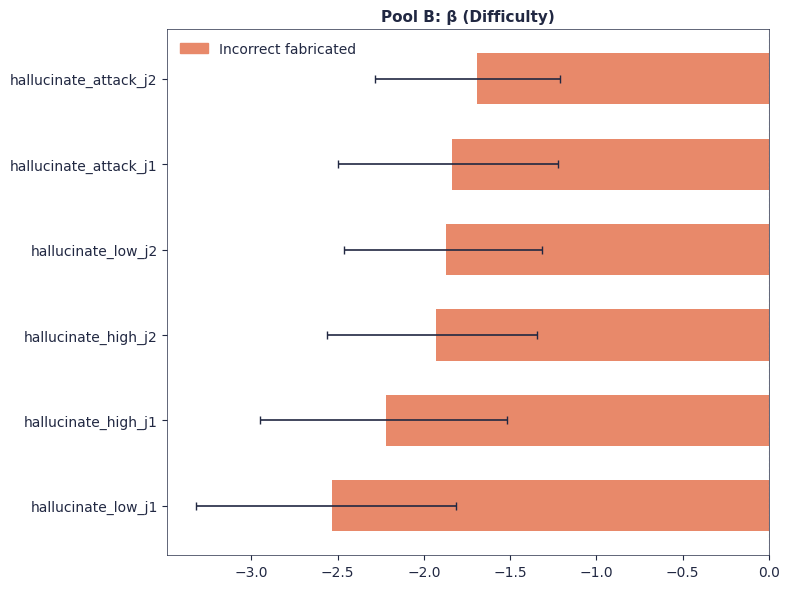

In [27]:
# 2PL-IRT: β (Item difficulty)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def get_color(item):
    return "#E8896A" if item.startswith("int") else "#E8896A"

background_color = "#ffffff"
item_irt_results = item_irt_results.sort_values("difficulty_mean", ascending=True)
colors = [get_color(i) for i in item_irt_results["item"]]
items = item_irt_results["item"]
y_pos = np.arange(len(items))

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

ax.barh(y_pos, item_irt_results["difficulty_mean"], color=colors, height=0.6)
ax.errorbar(
    item_irt_results["difficulty_mean"], y_pos,
    xerr=[
        item_irt_results["difficulty_mean"] - item_irt_results["difficulty_hdi_3%"],
        item_irt_results["difficulty_hdi_97%"] - item_irt_results["difficulty_mean"]
    ],
    fmt="none", color="#212842", linewidth=1.2, capsize=3
)
ax.set_yticks(y_pos)
ax.set_yticklabels(items, fontsize=10)
ax.set_title("Pool B: β (Difficulty)", fontsize=11, fontweight="bold", color="#212842")
ax.axvline(0, color="#212842", linewidth=0.8, linestyle="--", alpha=0.5)
ax.tick_params(colors="#212842")
for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)

int_patch = mpatches.Patch(color="#E8896A", label="Incorrect fabricated")
# ext_patch = mpatches.Patch(color="#E07B39", label="Incorrect external")
ax.legend(handles=[int_patch], loc="upper left",
          fontsize=10, frameon=False, labelcolor="#212842")

plt.tight_layout()
plt.savefig("irt_difficulty.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()


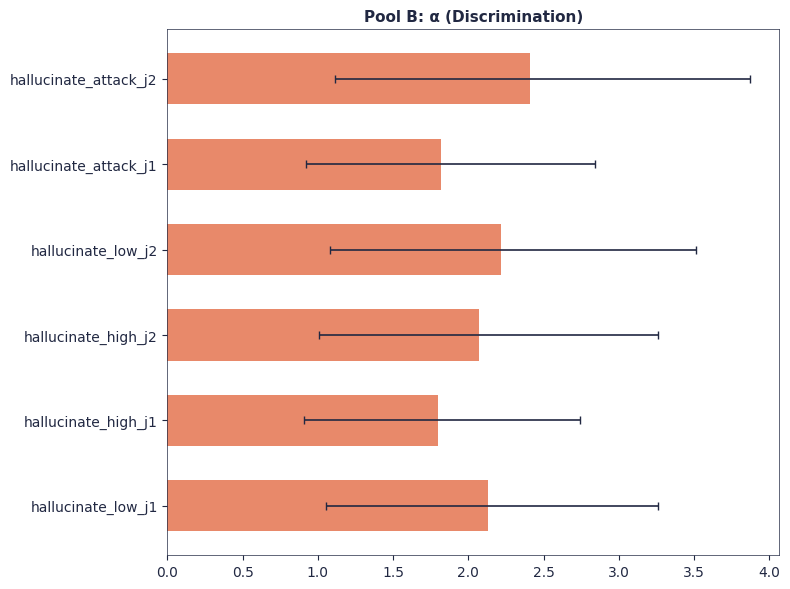

In [28]:
# 2PL-IRT: α (Item discrimination)
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

ax.barh(y_pos, item_irt_results["discrimination_mean"], color=colors, height=0.6)
ax.errorbar(
    item_irt_results["discrimination_mean"], y_pos,
    xerr=[
        item_irt_results["discrimination_mean"] - item_irt_results["discrimination_hdi_3%"],
        item_irt_results["discrimination_hdi_97%"] - item_irt_results["discrimination_mean"]
    ],
    fmt="none", color="#212842", linewidth=1.2, capsize=3
)
ax.set_yticks(y_pos)
ax.set_yticklabels(items, fontsize=10)
ax.set_title("Pool B: α (Discrimination)", fontsize=11, fontweight="bold", color="#212842")
ax.tick_params(colors="#212842")
for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)

# int_patch = mpatches.Patch(color="#E8896A", label="Incorrect fabricated")
# ext_patch = mpatches.Patch(color="#E07B39", label="Incorrect external")
# ax.legend(handles=[int_patch], loc="upper right",
#           fontsize=10, frameon=False, labelcolor="#212842")

plt.tight_layout()
plt.savefig("irt_discrimination.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()


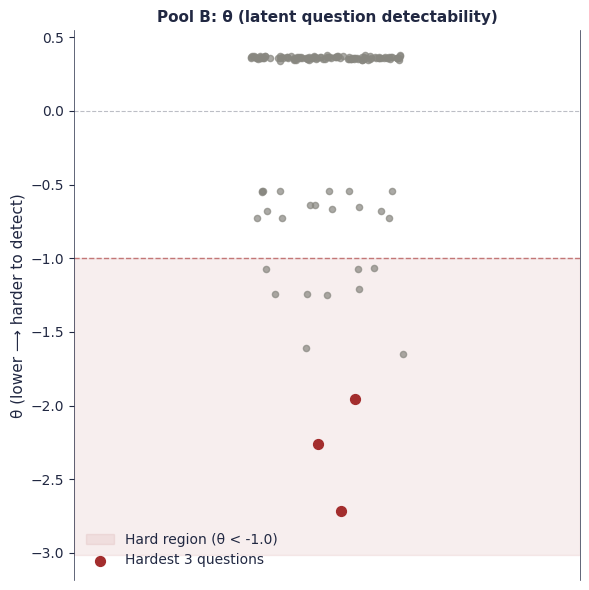

In [29]:
# 2PL-IRT:
background_color = "#ffff"
main_color = "#888780"
outlier_color = "#A32D2D"
threshold = -1.0
n_highlight = 3
jitter_strength = 0.15

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)

question_irt_results_sorted = question_irt_results.sort_values("theta_mean", ascending=True).reset_index(drop=True)
y = question_irt_results_sorted["theta_mean"].values

# Jitter x positions
x = np.random.uniform(-jitter_strength, jitter_strength, size=len(y))

# Shaded hard region
ax.axhspan(y.min() - 0.3, threshold, color="#A32D2D", alpha=0.08,
           label=f"Hard region (θ < {threshold})")
ax.axhline(threshold, color="#A32D2D", linewidth=1.0, linestyle="--", alpha=0.6)
ax.axhline(0, color="#212842", linewidth=0.8, linestyle="--", alpha=0.3)

# Main dots
hardest_mask = np.zeros(len(y), dtype=bool)
hardest_mask[:n_highlight] = True

ax.scatter(x[~hardest_mask], y[~hardest_mask],
           color=main_color, s=20, alpha=0.7, zorder=5)
ax.scatter(x[hardest_mask], y[hardest_mask],
           color=outlier_color, s=50, zorder=6,
           label=f"Hardest {n_highlight} questions")

ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("θ (lower ⟶ harder to detect)", fontsize=11, color="#212842")
ax.set_title("Pool B: θ (latent question detectability)", fontsize=11, fontweight="bold", color="#212842")
ax.tick_params(colors="#212842")
ax.legend(fontsize=10, frameon=False, labelcolor="#212842")

for spine in ax.spines.values():
    spine.set_edgecolor("#212842")
    spine.set_linewidth(0.5)
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig("irt_latent_qn.png", dpi=150, bbox_inches="tight", facecolor=background_color)
plt.show()

